(891, 12)
10692
<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                     

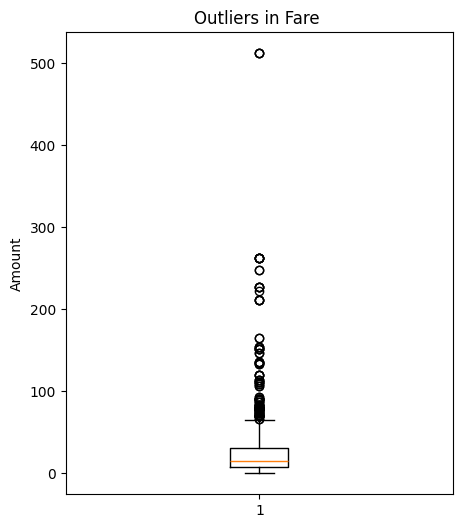

Q1: 7.9104
Q3:   31.0
IQR:  23.0896
upper quartile range : 65.6344
lower quartile range : -26.724
Total outliers: 116

Max Fare: 512.3292
Min Fare: 0.0
count    891.000000
mean      24.046813
std       20.481625
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max       65.634400
Name: Fare, dtype: float64

Max Fare: 65.6344
Min Fare: 0.0


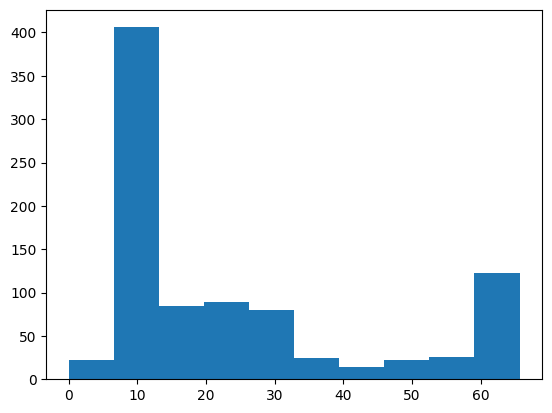

        Age      Fare
0 -0.592481 -0.820552
1  0.638789  2.031623
2 -0.284663 -0.787578
3  0.407926  1.419297
4  0.407926 -0.781471
X_train: (712, 7)
X_test: (179, 7)
y_train: (712,)
y_test: (179,)


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('Titanic-Dataset.csv')
print(df.shape)
print(df.size)
print(df.head)
print(df.isnull().sum())
df['Age'] = df['Age'].fillna(df['Age'].mean())
print(df['Age'].isnull().sum())
df = df.drop(columns=['Cabin'])
print(df.shape)

df['Embarked'] =df['Embarked'].fillna(df['Embarked'].mode()[0])
print(df['Embarked'].isnull().sum())
print(df.isnull().sum())
#   Label Encoding 
em = LabelEncoder()
df['Name_encoded'] =  em.fit_transform(df['Name'] )
print(df[['Name', 'Name_encoded']])
df = df.drop(columns=['Name'])
sex = LabelEncoder()
df['Sex_encoded'] = sex.fit_transform(df['Sex'])
print(df[['Sex', 'Sex_encoded']])
print(df.shape)

# one hotencoding 
df = pd.get_dummies(df,  columns=['Embarked'])
print('after one hotenconding' ,df.shape)
print(df.head())
df['Embarked_C'] = df['Embarked_C'].astype(int)
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)
print(df[['Embarked_C' , 'Embarked_Q' ,'Embarked_S']].head())
# Outliers detecton 
plt.figure(figsize=(5,6))
plt.boxplot(df['Fare'])
plt.title('Outliers in Fare ')
plt.ylabel('Amount')
plt.show()
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5 *IQR
upper = Q3 + 1.5 *IQR
print(f"Q1: {Q1}")
print(f"Q3:   {Q3}")
print(f"IQR:  {IQR}")
print(f"upper quartile range : {upper}")
print(f"lower quartile range : {lower}")
# outliers calculete 
outliers = df[(df['Fare']<lower)  | (df['Fare']>upper)]
print("Total outliers:", len(outliers))
print("\nMax Fare:", df['Fare'].max())
print("Min Fare:", df['Fare'].min())

# Clipping 

df['Fare'] = df['Fare'].clip(lower= 0, upper=65.6344)

print(df['Fare'].describe())
print("\nMax Fare:", df['Fare'].max())
print("Min Fare:", df['Fare'].min())
plt.hist(df['Fare'])
plt.show()
#  Feature Scaling // Due to skewed data we use  Standardscaling 

Scalar = StandardScaler()
df[['Age', 'Fare']] = Scalar.fit_transform(df[['Age','Fare']])
print(df[['Age','Fare']].head())

# training and testing the data 
from sklearn.model_selection import train_test_split

X = df[['Pclass', 'Age', 'Fare', 
        'Sex_encoded', 'Embarked_C',
        'Embarked_Q', 'Embarked_S']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)